[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


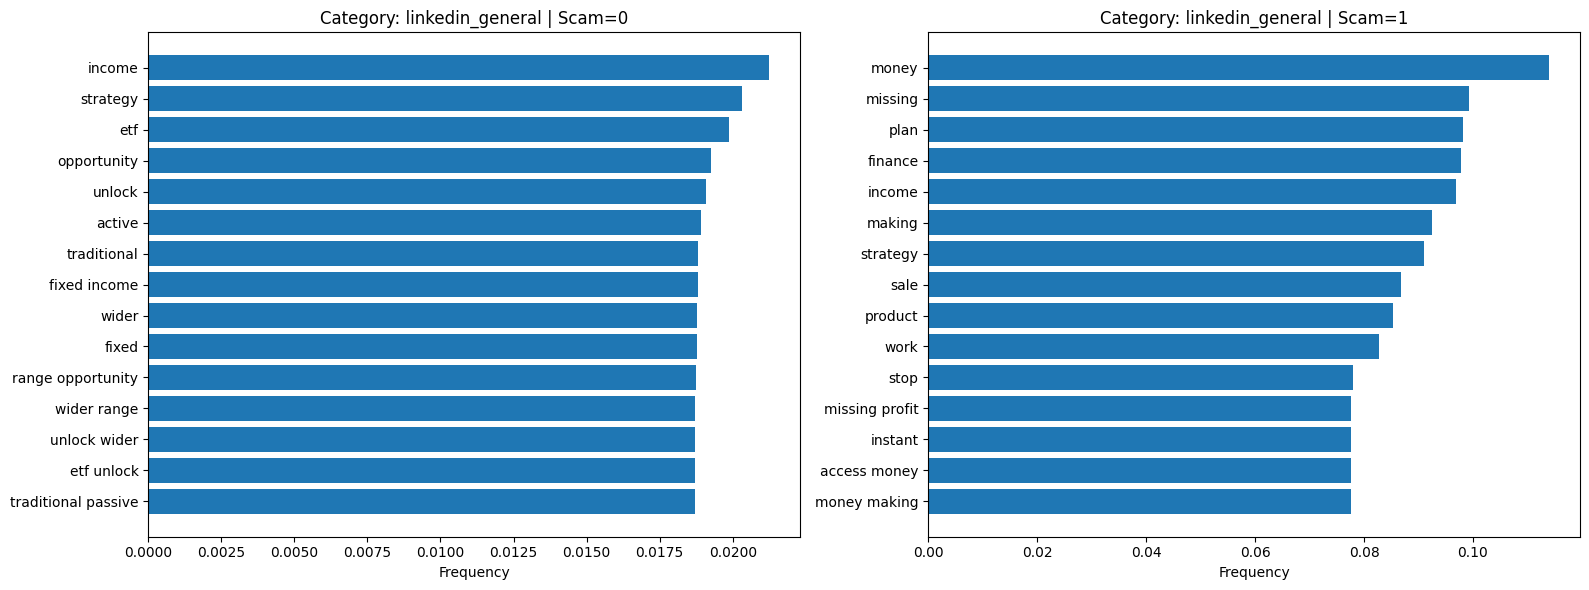

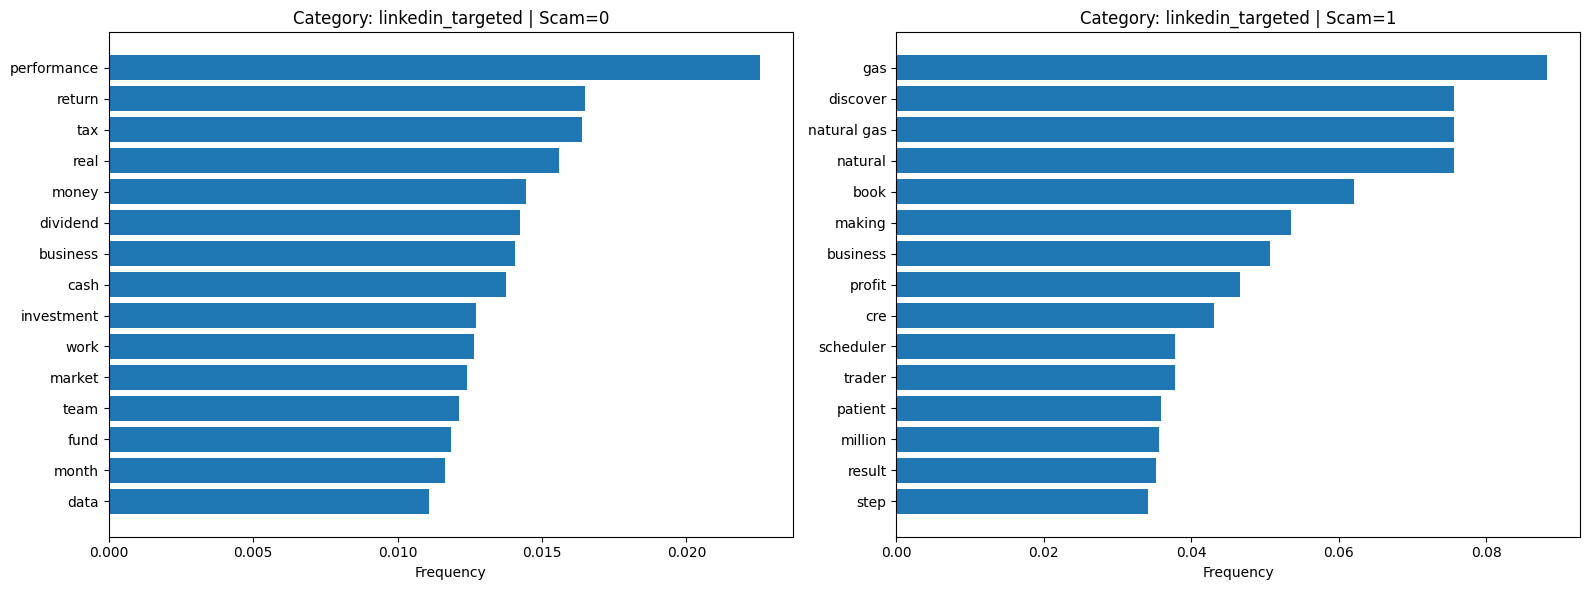

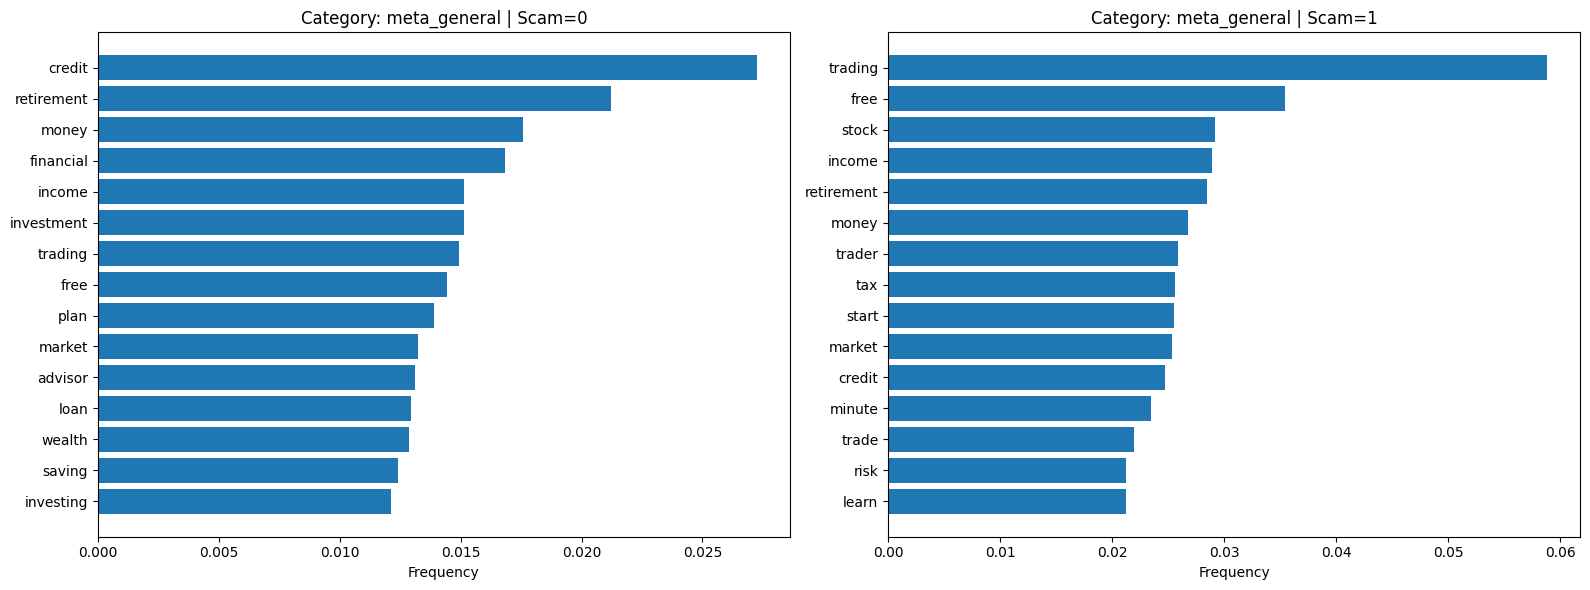

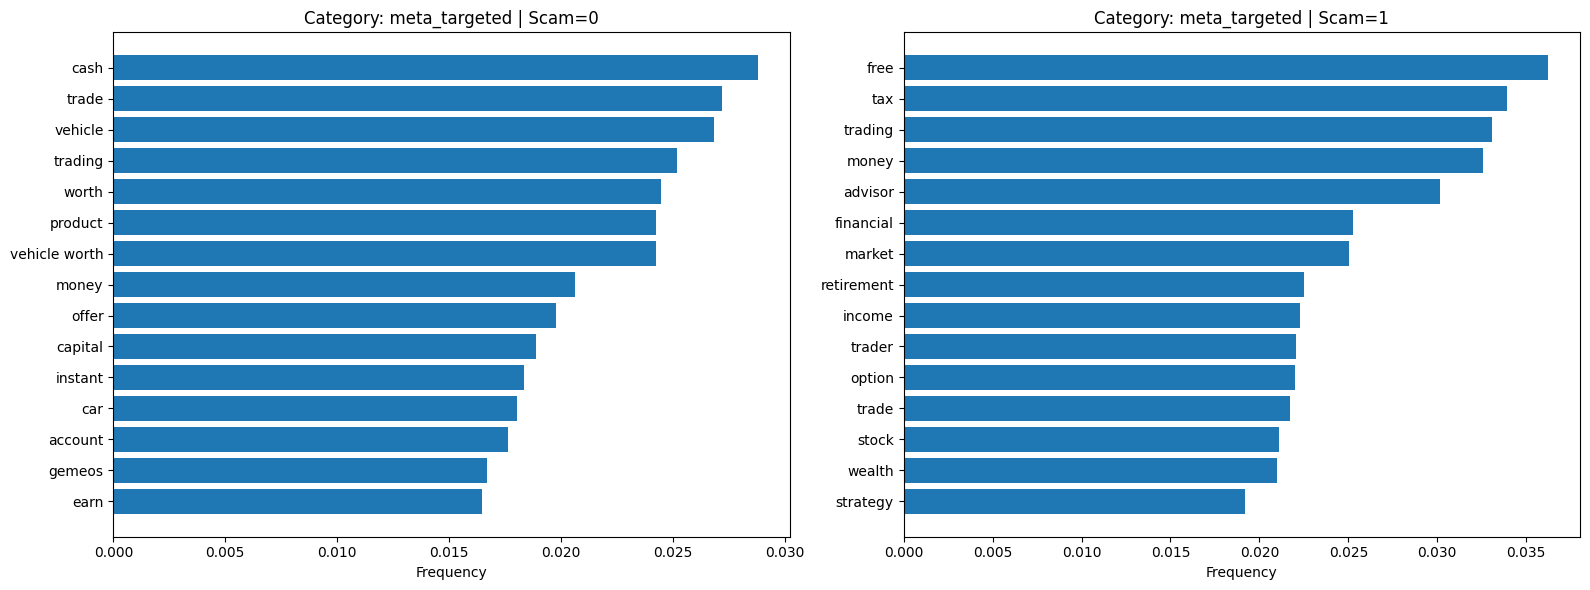

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter

# =========================================================
# 1. DOWNLOAD NLTK RESOURCES (RUN ONCE)
# =========================================================

nltk.download("stopwords")
nltk.download("wordnet")

# =========================================================
# 2. LOAD DATA
# =========================================================

df = pd.read_excel("/Volumes/点我点我/all/Senior Spring/COS/for content analysis.xlsx")

# Keep only needed columns
df = df[[
    "unique_id",
    "category",
    "ad_text",
    "total_score",
    "scam"
]]

# Remove missing text
df = df.dropna(subset=["ad_text"])

# =========================================================
# 3. PREPROCESSING
# =========================================================

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

# Add custom stopwords common in ads
stop_words.update([

    # generic verbs
    "get", "make", "take", "know", "see",
    "feel", "want", "need", "help",

    # generic nouns
    "day", "year", "week", "time",
    "people", "person", "way", "thing",

    # ad filler
    "join", "today", "new", "great",
    "best", "looking", "required",

    # boilerplate
    "including", "ability", "must",
    "qualified", "applicant",

    # low-information words
    "one", "even", "also", "well",
    "many", "much", "lot", "actually"
])

def preprocess(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove emails
    text = re.sub(r"\S+@\S+", "", text)

    # Remove phone numbers
    text = re.sub(r"\b\d+\b", "", text)

    # Remove punctuation / non-letters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords + short words
    words = [
        w for w in words
        if w not in stop_words and len(w) > 2
    ]

    # Lemmatize
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

# Apply cleaning
df["clean_text"] = df["ad_text"].apply(preprocess)

# =========================================================
# 4. FUNCTION TO GET TOP WORDS + BIGRAMS
# =========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_terms_tfidf(texts, top_n=15):

    vectorizer = TfidfVectorizer(
        stop_words="english",

        # unigrams + bigrams
        ngram_range=(1, 2),

        # ignore extremely common terms
        max_df=0.7,

        # ignore extremely rare terms
        min_df=2
    )

    X = vectorizer.fit_transform(texts)

    scores = np.asarray(X.mean(axis=0)).flatten()

    vocab = vectorizer.get_feature_names_out()

    tfidf_df = pd.DataFrame({
        "term": vocab,
        "score": scores
    })

    tfidf_df = tfidf_df.sort_values(
        by="score",
        ascending=False
    )

    return tfidf_df.head(top_n)

# =========================================================
# 5. VISUALIZATION
# =========================================================

categories = sorted(df["category"].unique())

for cat in categories:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 6)
    )

    for j, scam_value in enumerate([0, 1]):

        subset = df[
            (df["category"] == cat) &
            (df["scam"] == scam_value)
        ]

        # Skip empty groups
        if len(subset) == 0:
            continue

        top_terms = get_top_terms_tfidf(
            subset["clean_text"],
            top_n=15
        )

        # Reverse for horizontal bar chart
        top_terms = top_terms.iloc[::-1]

        axes[j].barh(
            top_terms["term"],
            top_terms["score"]
        )

        axes[j].set_title(
            f"Category: {cat} | Scam={scam_value}"
        )

        axes[j].set_xlabel("Frequency")

    plt.tight_layout()
    plt.savefig(
        f"/Volumes/点我点我/all/Senior Spring/COS/category_{cat}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
